## Load the Data Set

In [1]:
import pandas as pd

train = pd.read_csv('dataset\\train.csv')
test = pd.read_csv('dataset\\test.csv')
sample_submission = pd.read_csv('dataset\\sample_submission.csv')


In [2]:
train.shape

(20000, 17)

In [3]:
test.shape

(12000, 16)

In [4]:
train.head()

,id,temperature,irradiance,humidity,panel_age,maintenance_count,soiling_ratio,voltage,current,module_temperature,cloud_coverage,wind_speed,pressure,string_id,error_code,installation_type,efficiency
0,0,7.817315,576.179270,41.24308670850264,32.135501,4.0,0.803199,37.403527,1.963787,13.691147,62.494044,12.82491203459621,1018.8665053152533,A1,NaN,NaN,0.562096
1,1,24.785727,240.003973,1.3596482765960705,19.977460,8.0,0.479456,21.843315,0.241473,27.545096,43.851238,12.012043660984917,1025.6238537572883,D4,E00,dual-axis,0.396447
2,2,46.652695,687.612799,91.26536837560256,1.496401,4.0,0.822398,48.222882,4.191800,43.363708,NaN,1.814399755560454,1010.9226539809573,C3,E00,NaN,0.573776
3,3,53.339567,735.141179,96.19095521176159,18.491582,3.0,0.837529,46.295748,0.960567,57.720436,67.361473,8.736258932034128,1021.8466633134253,A1,NaN,dual-axis,0.629009
4,4,5.575374,12.241203,27.495073003585226,30.722697,6.0,0.551833,0.000000,0.898062,6.786263,3.632000,0.52268384077164,1008.5559577591927,B2,E00,fixed,0.341874


In [5]:
test.isnull().sum()
train.isnull().sum()


id                       0
temperature           1001
irradiance             987
humidity                 0
panel_age             1011
maintenance_count     1027
soiling_ratio         1010
voltage                993
current                977
module_temperature     978
cloud_coverage        1010
wind_speed               0
pressure                 0
string_id                0
error_code            5912
installation_type     5028
efficiency               0
dtype: int64

In [6]:
# Median imputation
median_cols = [
    'temperature', 'irradiance', 'maintenance_count',
    'soiling_ratio', 'voltage', 'current', 
    'module_temperature', 'cloud_coverage'
]
for col in median_cols:
    train[col] = train[col].fillna(train[col].median())

# Mean imputation
train['panel_age'] = train['panel_age'].fillna(train['panel_age'].mean())

# Mode imputation for categorical
mode_cols = ['error_code', 'installation_type']
for col in mode_cols:
    train[col] = train[col].fillna(train[col].mode()[0])


In [7]:
train.isnull().sum()
# test.isnull().sum()


id                    0
temperature           0
irradiance            0
humidity              0
panel_age             0
maintenance_count     0
soiling_ratio         0
voltage               0
current               0
module_temperature    0
cloud_coverage        0
wind_speed            0
pressure              0
string_id             0
error_code            0
installation_type     0
efficiency            0
dtype: int64

In [8]:
train.dtypes


id                      int64
temperature           float64
irradiance            float64
humidity               object
panel_age             float64
maintenance_count     float64
soiling_ratio         float64
voltage               float64
current               float64
module_temperature    float64
cloud_coverage        float64
wind_speed             object
pressure               object
string_id              object
error_code             object
installation_type      object
efficiency            float64
dtype: object

## Outlier treatment

In [11]:
numerical_cols = [
    'temperature', 'irradiance', 'humidity', 'panel_age',
    'maintenance_count', 'soiling_ratio', 'voltage',
    'current', 'module_temperature', 'cloud_coverage',
    'wind_speed', 'pressure'
]


In [12]:
def iqr_clip(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)
    return df

# Apply to train
train = iqr_clip(train, numerical_cols)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

Matplotlib is building the font cache; this may take a moment.


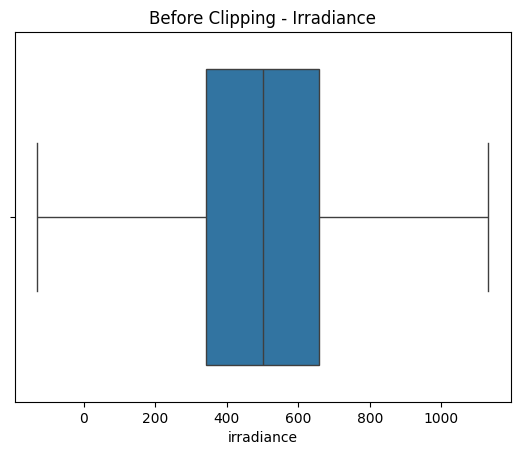

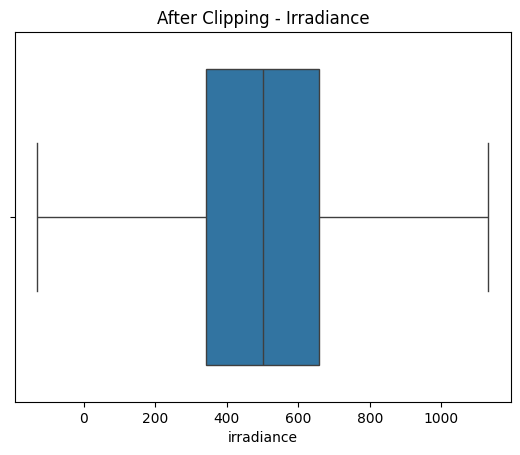

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Before clipping
sns.boxplot(x=train['irradiance'])
plt.title("Before Clipping - Irradiance")
plt.show()

# After clipping
train_clipped = iqr_clip(train.copy(), ['irradiance'])
sns.boxplot(x=train_clipped['irradiance'])
plt.title("After Clipping - Irradiance")
plt.show()


In [9]:
categorical_cols = ['string_id', 'error_code', 'installation_type']
for col in categorical_cols:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')


In [10]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['string_id', 'error_code', 'installation_type']
le_dict = {}

for col in label_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])
    le_dict[col] = le


KeyboardInterrupt: 